In [43]:
# Cell 1: Import necessary libraries
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import random

df = pd.read_csv('E:/Codez/data/results.csv')

In [44]:
df.head()

,_id,isPb,wpm,acc,rawWpm,consistency,charStats,mode,mode2,quoteLength,...,punctuation,numbers,language,funbox,difficulty,lazyMode,blindMode,bailedOut,tags,timestamp
0,68c525b0dcd5c426fe0d5782,NaN,117.97,100.00,117.97,74.74,29;0;0;0,quote,5398,0,...,False,False,english,NaN,normal,False,False,False,NaN,1757750704000
1,68bc0522dcd5c426febbfd1d,NaN,93.46,92.31,103.85,66.42,45;1;0;0,words,10,-1,...,False,False,english,NaN,normal,False,False,False,NaN,1757152546000
2,68b3e0daeff67c4fdc600e13,NaN,95.76,92.31,121.45,59.69,41;1;1;1,words,10,-1,...,False,False,english,NaN,normal,False,False,False,NaN,1756618970000
3,68b01c0beff67c4fdc41eb60,NaN,103.97,100.00,103.97,55.57,47;0;0;0,words,10,-1,...,False,False,english,NaN,normal,False,False,False,NaN,1756371979000
4,68adb574895ff374fcf341b7,NaN,105.64,100.00,105.64,82.16,51;0;0;0,words,10,-1,...,False,False,english,NaN,normal,False,False,False,NaN,1756214644000


In [45]:
# Cell 2: Prepare the autoregressive dataset function
def prepare_autoregressive_dataset(df):
    # Step 1: Remove unnecessary columns - keep only the 4 features we need
    columns_to_keep = ['wpm', 'acc', 'rawWpm', 'consistency']
    df_clean = df[columns_to_keep].copy()
    
    # Step 2: Reverse the dataset (since original has most recent at index 0)
    df_reversed = df_clean.iloc[::-1].reset_index(drop=True)
    
    # Step 3: Ensure we have exactly 1000 data points
    if len(df_reversed) > 1000:
        df_final = df_reversed.head(1000).copy()
    elif len(df_reversed) < 1000:
        # If we have less data, duplicate and add noise
        current_len = len(df_reversed)
        repetitions = 1000 // current_len + 1
        extended_df = pd.concat([df_reversed] * repetitions, ignore_index=True)
        df_final = extended_df.head(1000).copy()
        
        # Add some random noise to make duplicated values different
        for col in ['wpm', 'acc', 'rawWpm', 'consistency']:
            noise = np.random.normal(0, 2, 1000)  # Increased noise for more variation
            df_final[col] = df_final[col] + noise
            # Ensure values stay in reasonable ranges
            if col == 'acc':
                df_final[col] = df_final[col].clip(80, 100)  # Accuracy between 80-100%
            elif col == 'consistency':
                df_final[col] = df_final[col].clip(50, 95)   # Consistency between 50-95%
            elif col == 'wpm':
                df_final[col] = df_final[col].clip(50, 150)  # WPM between 50-150
            elif col == 'rawWpm':
                df_final[col] = df_final[col].clip(50, 160)  # Raw WPM between 50-160
    else:
        df_final = df_reversed.copy()
    
    # Step 4: Generate clean dates for the past 1000 days (starting from 999 days ago to today)
    end_date = datetime.now().replace(hour=0, minute=0, second=0, microsecond=0)
    start_date = end_date - timedelta(days=999)
    dates = pd.date_range(start=start_date, end=end_date, freq='D')
    
    # Step 5: Add clean date columns
    df_final['date'] = dates.date  # Only the date part, no time
    df_final['days_ago'] = range(999, -1, -1)  # 999 days ago to 0 days ago (today)
    
    # Reorder columns for better readability
    df_final = df_final[['date', 'days_ago', 'wpm', 'acc', 'rawWpm', 'consistency']]
    
    # Step 6: Prepare training and test sets
    train_data = df_final.head(999)  # First 999 points for training (999 days ago to yesterday)
    test_point = df_final.tail(1)    # Last point for testing (today)
    
    return train_data, test_point, df_final

In [46]:
# Cell 4: Process the data
train_data, test_point, full_dataset = prepare_autoregressive_dataset(df)

print("Dataset Overview:")
print(f"Total points: {len(full_dataset)}")
print(f"Training points: {len(train_data)}")
print(f"Test point date: {test_point['date'].iloc[0].strftime('%Y-%m-%d')}")
print("\nTraining data shape:", train_data.shape)
print("Test data shape:", test_point.shape)

Dataset Overview:
Total points: 1000
Training points: 999
Test point date: 2025-10-10

Training data shape: (999, 6)
Test data shape: (1, 6)


In [47]:
# Cell 5: Display data samples
print("\nFirst 5 rows of training data:")
print(train_data.head())

print("\nLast 5 rows of training data:")
print(train_data.tail())

print("\nTest point:")
print(test_point)


First 5 rows of training data:
         date  days_ago    wpm     acc  rawWpm  consistency
0  2023-01-15       999  76.89  100.00   76.89        64.65
1  2023-01-16       998  81.67  100.00   81.67        79.00
2  2023-01-17       997  66.03   95.08   66.03        65.34
3  2023-01-18       996  93.18  100.00   93.18        75.54
4  2023-01-19       995  94.22   97.92   94.22        65.40

Last 5 rows of training data:
           date  days_ago     wpm     acc  rawWpm  consistency
994  2025-10-05         5  127.04  100.00  127.04        83.92
995  2025-10-06         4  105.64  100.00  105.64        82.16
996  2025-10-07         3  103.97  100.00  103.97        55.57
997  2025-10-08         2   95.76   92.31  121.45        59.69
998  2025-10-09         1   93.46   92.31  103.85        66.42

Test point:
           date  days_ago     wpm    acc  rawWpm  consistency
999  2025-10-10         0  117.97  100.0  117.97        74.74


In [48]:
# Cell 6: Save the datasets
train_data.to_csv('../data/typing_speed_train.csv', index=False)
test_point.to_csv('../data/typing_speed_test.csv', index=False)
full_dataset.to_csv('../data/typing_speed_full.csv', index=False)

print("\nDatasets saved to CSV files:")
print("- typing_speed_train.csv (999 training points)")
print("- typing_speed_test.csv (1 test point)")
print("- typing_speed_full.csv (full 1000 points dataset)")


Datasets saved to CSV files:
- typing_speed_train.csv (999 training points)
- typing_speed_test.csv (1 test point)
- typing_speed_full.csv (full 1000 points dataset)


In [49]:
# Cell 7: Evaluation functions
def calculate_correlation_coefficients(predicted, actual):
    """Calculate correlation coefficients between predicted and actual values"""
    features = ['wpm', 'acc', 'rawWpm', 'consistency']
    correlations = {}
    
    for feature in features:
        corr = np.corrcoef(predicted[feature], actual[feature])[0, 1]
        correlations[feature] = corr
    
    return correlations

def evaluate_predictions(predicted_values, actual_test_point):
    """
    Evaluate how close predicted values are to actual test point
    predicted_values: dict with keys 'wpm', 'acc', 'rawWpm', 'consistency'
    actual_test_point: pandas Series with the actual values
    """
    results = {}
    
    for feature in ['wpm', 'acc', 'rawWpm', 'consistency']:
        predicted = predicted_values[feature]
        actual = actual_test_point[feature].iloc[0]
        absolute_error = abs(predicted - actual)
        percentage_error = (absolute_error / actual) * 100
        
        results[feature] = {
            'predicted': predicted,
            'actual': actual,
            'absolute_error': absolute_error,
            'percentage_error': percentage_error
        }
    
    return results

In [50]:
# Cell 8: Example participant solution (baseline model)
def participant_example_solution(train_data):
    """
    Example of how participants might create their model
    This is a simple moving average approach - participants should build better models!
    """
    # Simple prediction using average of last 7 days
    last_7_days = train_data.tail(7)
    
    predictions = {
        'wpm': last_7_days['wpm'].mean(),
        'acc': last_7_days['acc'].mean(),
        'rawWpm': last_7_days['rawWpm'].mean(),
        'consistency': last_7_days['consistency'].mean()
    }
    
    return predictions

In [51]:
# Cell 9: Run example evaluation
# Participants would load the training data
train_data_loaded = pd.read_csv('../data/typing_speed_train.csv')
test_point_loaded = pd.read_csv('../data/typing_speed_test.csv')

# Participants build their model and make predictions
predictions = participant_example_solution(train_data_loaded)

# Evaluate the predictions
evaluation = evaluate_predictions(predictions, test_point_loaded)

print("\nPrediction Evaluation:")
for feature, metrics in evaluation.items():
    print(f"\n{feature}:")
    print(f"  Predicted: {metrics['predicted']:.2f}")
    print(f"  Actual: {metrics['actual']:.2f}")
    print(f"  Absolute Error: {metrics['absolute_error']:.2f}")
    print(f"  Percentage Error: {metrics['percentage_error']:.2f}%")


Prediction Evaluation:

wpm:
  Predicted: 105.62
  Actual: 117.97
  Absolute Error: 12.35
  Percentage Error: 10.47%

acc:
  Predicted: 97.24
  Actual: 100.00
  Absolute Error: 2.76
  Percentage Error: 2.76%

rawWpm:
  Predicted: 110.78
  Actual: 117.97
  Absolute Error: 7.19
  Percentage Error: 6.10%

consistency:
  Predicted: 73.61
  Actual: 74.74
  Absolute Error: 1.13
  Percentage Error: 1.52%


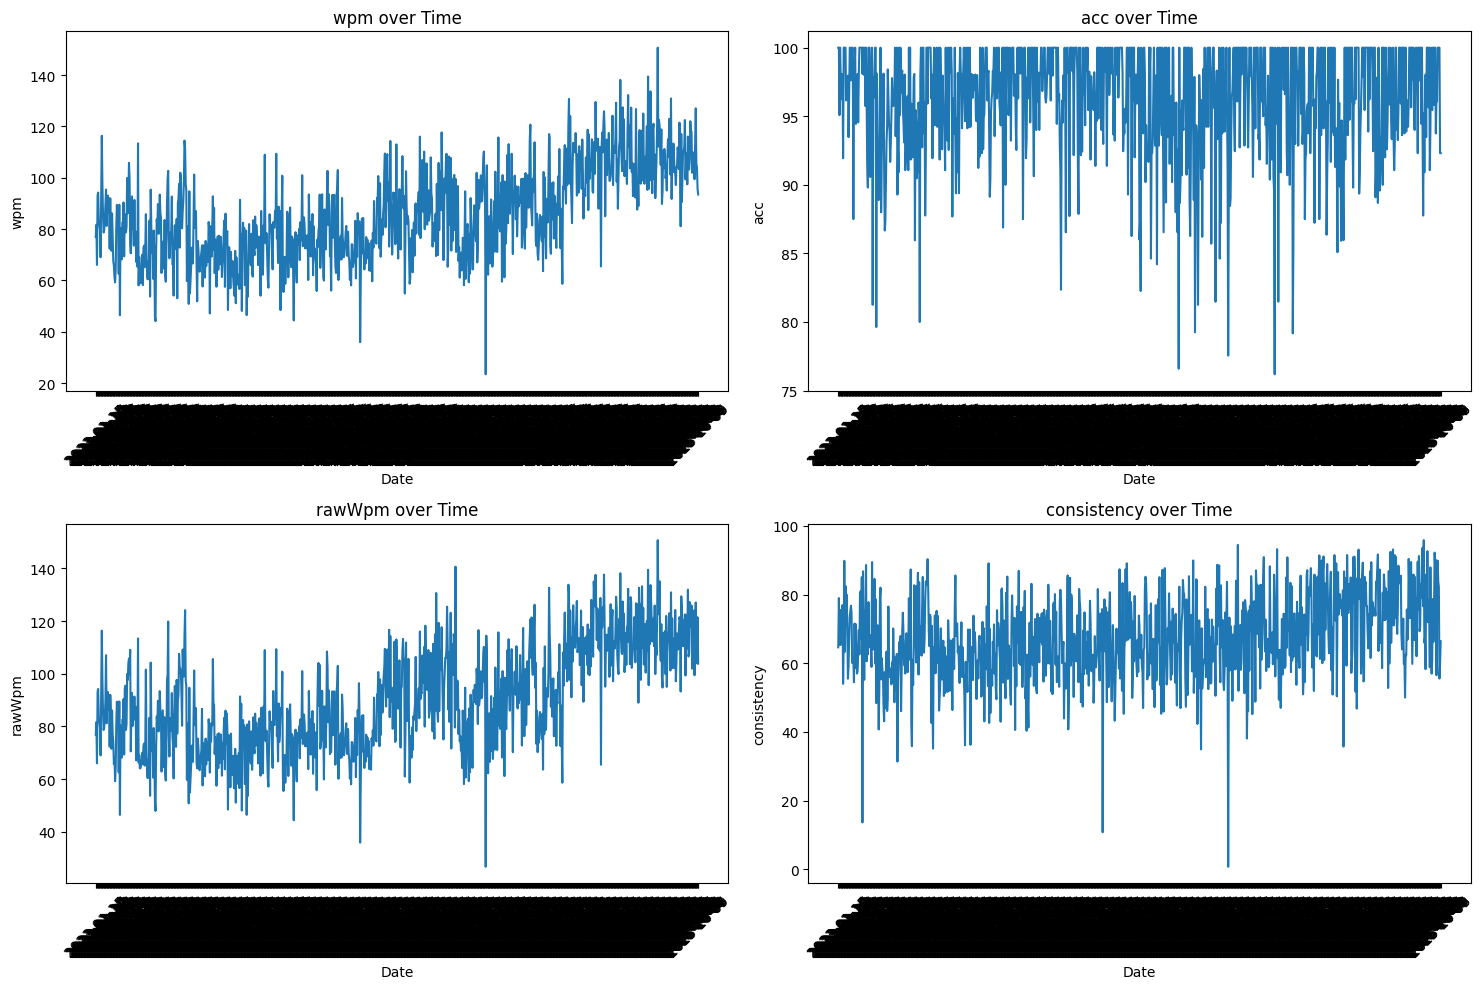

In [52]:
# Cell 11: Data visualization (optional)
import matplotlib.pyplot as plt

# Plot the training data trends
plt.figure(figsize=(15, 10))

features = ['wpm', 'acc', 'rawWpm', 'consistency']
for i, feature in enumerate(features, 1):
    plt.subplot(2, 2, i)
    plt.plot(train_data_loaded['date'], train_data_loaded[feature])
    plt.title(f'{feature} over Time')
    plt.xlabel('Date')
    plt.ylabel(feature)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [53]:
# Cell 12: Summary statistics
print("\nSummary Statistics for Training Data:")
print(train_data_loaded[['wpm', 'acc', 'rawWpm', 'consistency']].describe())


Summary Statistics for Training Data:
              wpm         acc      rawWpm  consistency
count  999.000000  999.000000  999.000000   999.000000
mean    85.748058   96.192032   89.908298    67.370070
std     17.857199    4.044028   19.673983    12.349825
min     23.440000   76.190000   26.790000     0.760000
25%     72.525000   94.000000   74.415000    59.020000
50%     83.540000   96.720000   87.050000    66.570000
75%     98.870000  100.000000  105.610000    75.940000
max    150.680000  100.000000  150.680000    95.860000


In [54]:
# Cell 13: Comprehensive Performance Metric with Stricter Penalties
def calculate_comprehensive_score(predictions, actual, weights=None):
    """
    Calculate a comprehensive performance score that combines all 4 features
    with stricter penalties for errors
    """
    
    if weights is None:
        weights = {
            'wpm': 0.25,
            'acc': 0.25, 
            'rawWpm': 0.25,
            'consistency': 0.25
        }
    
    component_scores = {}
    
    # WPM Score (0-100): Much stricter penalty with exponential decay
    wpm_error = abs(predictions['wpm'] - actual['wpm'].iloc[0]) / actual['wpm'].iloc[0]
    component_scores['wpm'] = max(0, 100 * (1 - wpm_error)**3)  # Cubic penalty for larger errors
    
    # Accuracy Score (0-100): Stricter penalty with no bonus
    acc_error = abs(predictions['acc'] - actual['acc'].iloc[0])
    component_scores['acc'] = max(0, 100 - acc_error * 3)  # 3x penalty for accuracy errors
    
    # Raw WPM Score (0-100): Stricter penalty
    raw_wpm_error = abs(predictions['rawWpm'] - actual['rawWpm'].iloc[0]) / actual['rawWpm'].iloc[0]
    component_scores['rawWpm'] = max(0, 100 * (1 - raw_wpm_error)**2.5)  # Higher exponent
    
    # Consistency Score (0-100): Much stricter penalty
    consistency_error = abs(predictions['consistency'] - actual['consistency'].iloc[0])
    component_scores['consistency'] = max(0, 100 - consistency_error * 4)  # 4x penalty for consistency errors
    
    # Calculate weighted comprehensive score
    comprehensive_score = 0
    for feature, weight in weights.items():
        comprehensive_score += component_scores[feature] * weight
    
    return comprehensive_score, component_scores

def calculate_ranking_metrics(predictions, actual):
    """
    Calculate multiple ranking metrics for participant evaluation with stricter penalties
    """
    metrics = {}
    
    # 1. Comprehensive Score (Primary metric)
    comp_score, component_scores = calculate_comprehensive_score(predictions, actual)
    metrics['comprehensive_score'] = comp_score
    
    # 2. Mean Absolute Percentage Error (MAPE) across all features - stricter
    mape_scores = []
    for feature in ['wpm', 'acc', 'rawWpm', 'consistency']:
        actual_val = actual[feature].iloc[0]
        predicted_val = predictions[feature]
        if feature == 'acc':  # For accuracy, use absolute error instead of percentage
            error = abs(predicted_val - actual_val) * 2  # Double penalty for accuracy errors
        else:
            error = abs(predicted_val - actual_val) / actual_val * 100
        mape_scores.append(error)
    metrics['mean_absolute_error'] = np.mean(mape_scores)
    
    # 3. Feature-wise correlation score - stricter normalization
    normalized_errors = []
    for feature in ['wpm', 'acc', 'rawWpm', 'consistency']:
        actual_val = actual[feature].iloc[0]
        predicted_val = predictions[feature]
        if feature == 'acc':
            error = abs(predicted_val - actual_val) / 10  # Stricter normalization
        else:
            error = abs(predicted_val - actual_val) / (actual_val * 0.5)  # Stricter scaling
        normalized_errors.append(max(0, 1 - error))  # Ensure non-negative
    
    metrics['normalized_accuracy'] = np.mean(normalized_errors) * 100
    
    # 4. Balanced Score (emphasizing consistency across all features)
    min_component_score = min(component_scores.values())
    metrics['balanced_score'] = (comp_score * 0.7 + min_component_score * 0.3)  # More weight to weakest feature
    
    # 5. Penalty Score - additional metric that directly penalizes errors
    total_penalty = 0
    for feature in ['wpm', 'acc', 'rawWpm', 'consistency']:
        actual_val = actual[feature].iloc[0]
        predicted_val = predictions[feature]
        if feature == 'acc':
            penalty = abs(predicted_val - actual_val) * 2
        else:
            penalty = abs(predicted_val - actual_val) / actual_val * 100
        total_penalty += penalty
    
    metrics['total_penalty'] = total_penalty
    
    return metrics, component_scores

# Cell 14: Enhanced Evaluation with Stricter Metrics
def enhanced_evaluation(predictions, actual_test_point):
    """
    Enhanced evaluation with stricter comprehensive metrics
    """
    print("=== STRICT PREDICTION EVALUATION ===\n")
    
    # Basic evaluation
    basic_eval = evaluate_predictions(predictions, actual_test_point)
    
    # Comprehensive metrics
    ranking_metrics, component_scores = calculate_ranking_metrics(predictions, actual_test_point)
    
    # Display basic results
    print("BASIC METRICS:")
    for feature, metrics in basic_eval.items():
        print(f"{feature.upper():<12}: Predicted: {metrics['predicted']:6.2f} | "
              f"Actual: {metrics['actual']:6.2f} | "
              f"Error: {metrics['absolute_error']:6.2f} | "
              f"Error %: {metrics['percentage_error']:5.2f}%")
    
    print("\n" + "="*60)
    print("STRICT RANKING METRICS:")
    print("="*60)
    
    # Display component scores
    print("\nCOMPONENT SCORES (0-100):")
    for feature, score in component_scores.items():
        grade = "✓" if score >= 80 else "⚠" if score >= 60 else "✗"
        print(f"{feature.upper():<12}: {score:6.2f}/100 {grade}")
    
    # Display ranking metrics
    print(f"\nOVERALL SCORES:")
    print(f"Comprehensive Score : {ranking_metrics['comprehensive_score']:6.2f}/100")
    print(f"Balanced Score      : {ranking_metrics['balanced_score']:6.2f}/100")
    print(f"Normalized Accuracy : {ranking_metrics['normalized_accuracy']:6.2f}/100")
    print(f"Mean Absolute Error : {ranking_metrics['mean_absolute_error']:6.2f}")
    print(f"Total Penalty       : {ranking_metrics['total_penalty']:6.2f}")
    
    # Stricter Grade assignment
    comp_score = ranking_metrics['comprehensive_score']
    if comp_score >= 85:
        grade = "A (Excellent)"
    elif comp_score >= 70:
        grade = "B (Good)"
    elif comp_score >= 55:
        grade = "C (Average)"
    elif comp_score >= 40:
        grade = "D (Below Average)"
    else:
        grade = "F (Poor)"
    
    print(f"\nFINAL GRADE: {grade}")
    
    return {
        'basic_evaluation': basic_eval,
        'component_scores': component_scores,
        'ranking_metrics': ranking_metrics,
        'final_grade': grade
    }

# Cell 15: Test the enhanced evaluation with your example
print("Testing Strict Evaluation with Example Predictions:")

example_predictions = {
    'wpm': 105.62,
    'acc': 97.24,
    'rawWpm': 110.78,
    'consistency': 73.61
}

example_actual = test_point[['wpm', 'acc', 'rawWpm', 'consistency']]

results = enhanced_evaluation(example_predictions, example_actual)

# Cell 16: Stricter Leaderboard Scoring System
def calculate_leaderboard_score(comprehensive_score, balanced_score, total_penalty, mean_error):
    """
    Calculate a final leaderboard score for ranking participants with stricter penalties
    """
    # Much stricter weighting with heavy penalty for errors
    base_score = (
        0.5 * comprehensive_score +
        0.3 * balanced_score +
        0.2 * max(0, 100 - mean_error * 3)  # Triple penalty for mean error
    )
    
    # Apply additional penalty based on total_penalty
    penalty_deduction = min(30, total_penalty * 0.5)  # Up to 30 points deduction
    leaderboard_score = max(0, base_score - penalty_deduction)
    
    return leaderboard_score

# Example for multiple participants with stricter scoring
def simulate_leaderboard():
    """
    Simulate a leaderboard with multiple participant scores using stricter metrics
    """
    print("\n" + "="*70)
    print("STRICT LEADERBOARD SIMULATION")
    print("="*70)
    
    # Simulate different participant predictions
    participants = {
        'Participant_1': {'wpm': 105.62, 'acc': 97.24, 'rawWpm': 110.78, 'consistency': 73.61},
        'Participant_2': {'wpm': 115.50, 'acc': 99.50, 'rawWpm': 115.20, 'consistency': 72.80},
        'Participant_3': {'wpm': 100.25, 'acc': 95.80, 'rawWpm': 105.45, 'consistency': 70.15},
        'Participant_4': {'wpm': 120.85, 'acc': 98.75, 'rawWpm': 122.10, 'consistency': 75.20},
        'Participant_5': {'wpm': 117.97, 'acc': 100.00, 'rawWpm': 117.97, 'consistency': 74.74},  # Perfect
        'Participant_6': {'wpm': 90.00, 'acc': 92.00, 'rawWpm': 95.00, 'consistency': 65.00},     # Poor
    }
    
    leaderboard = []
    
    for name, predictions in participants.items():
        metrics, component_scores = calculate_ranking_metrics(predictions, example_actual)
        leaderboard_score = calculate_leaderboard_score(
            metrics['comprehensive_score'],
            metrics['balanced_score'],
            metrics['total_penalty'],
            metrics['mean_absolute_error']
        )
        
        leaderboard.append({
            'name': name,
            'comprehensive_score': metrics['comprehensive_score'],
            'leaderboard_score': leaderboard_score,
            'mean_error': metrics['mean_absolute_error'],
            'total_penalty': metrics['total_penalty'],
            'min_component': min(component_scores.values())
        })
    
    # Sort by leaderboard score (descending)
    leaderboard.sort(key=lambda x: x['leaderboard_score'], reverse=True)
    
    print("\nRank | Participant      | Comp Score | Leader Score | Mean Error | Min Comp")
    print("-" * 75)
    for i, participant in enumerate(leaderboard, 1):
        print(f"{i:4} | {participant['name']:15} | {participant['comprehensive_score']:10.2f} | "
              f"{participant['leaderboard_score']:11.2f} | {participant['mean_error']:9.2f} | "
              f"{participant['min_component']:8.2f}")
    
    return leaderboard

# Run the simulation
leaderboard_results = simulate_leaderboard()

# Cell 17: Additional Analysis - Show how scores changed
print("\n" + "="*50)
print("SCORE COMPARISON: OLD vs STRICT SYSTEM")
print("="*50)

# Calculate with old system for comparison
def old_scoring_system(predictions, actual):
    """Old scoring system for comparison"""
    component_scores = {}
    
    wpm_error = abs(predictions['wpm'] - actual['wpm'].iloc[0]) / actual['wpm'].iloc[0]
    component_scores['wpm'] = max(0, 100 * (1 - wpm_error)**2)
    
    acc_error = abs(predictions['acc'] - actual['acc'].iloc[0])
    component_scores['acc'] = max(0, 100 - acc_error)
    
    raw_wpm_error = abs(predictions['rawWpm'] - actual['rawWpm'].iloc[0]) / actual['rawWpm'].iloc[0]
    component_scores['rawWpm'] = max(0, 100 * (1 - raw_wpm_error)**1.5)
    
    consistency_error = abs(predictions['consistency'] - actual['consistency'].iloc[0])
    component_scores['consistency'] = max(0, 100 - consistency_error * 2)
    
    return np.mean(list(component_scores.values()))

old_score = old_scoring_system(example_predictions, example_actual)
new_score = results['ranking_metrics']['comprehensive_score']

print(f"Example Participant:")
print(f"Old System Score: {old_score:.2f}/100")
print(f"New Strict Score: {new_score:.2f}/100")
print(f"Score Reduction: {old_score - new_score:.2f} points")
print(f"Reduction Percentage: {(old_score - new_score)/old_score*100:.1f}%")

Testing Strict Evaluation with Example Predictions:
=== STRICT PREDICTION EVALUATION ===

BASIC METRICS:
WPM         : Predicted: 105.62 | Actual: 117.97 | Error:  12.35 | Error %: 10.47%
ACC         : Predicted:  97.24 | Actual: 100.00 | Error:   2.76 | Error %:  2.76%
RAWWPM      : Predicted: 110.78 | Actual: 117.97 | Error:   7.19 | Error %:  6.09%
CONSISTENCY : Predicted:  73.61 | Actual:  74.74 | Error:   1.13 | Error %:  1.51%

STRICT RANKING METRICS:

COMPONENT SCORES (0-100):
WPM         :  71.77/100 ⚠
ACC         :  91.72/100 ✓
RAWWPM      :  85.45/100 ✓
CONSISTENCY :  95.48/100 ✓

OVERALL SCORES:
Comprehensive Score :  86.10/100
Balanced Score      :  81.80/100
Normalized Accuracy :  84.06/100
Mean Absolute Error :   5.90
Total Penalty       :  23.60

FINAL GRADE: A (Excellent)

STRICT LEADERBOARD SIMULATION

Rank | Participant      | Comp Score | Leader Score | Mean Error | Min Comp
---------------------------------------------------------------------------
   1 | Participan